In [1]:
import numpy as np
from time import process_time
import matplotlib.pyplot as plt
from scipy import interpolate  # Interpolation routines

In [1]:
# magics: ensures that any changes to the modules loaded below will be re-loaded automatically
%load_ext autoreload
%autoreload 2
%load_ext line_profiler

import os
import sys
#sys.path.append('/Users/jacobaspnissen/Desktop/Økonomi/Dynamic programming/Termpaper/termpaper_dynprog/Job Search/')
sys.path.append('/Users/albertolsen/Documents/Stud Polit/9. semester/Dynamic Programming/Exam/termpaper_dynprog/Job Search')
#print(os.getcwd())
#print(os.listdir("/Users/jacobaspnissen/Desktop/Økonomi/Dynamic programming/Termpaper/termpaper_dynprog/Job Search"))
import Model_components as model
import numpy as np
from time import process_time
import matplotlib.pyplot as plt
from scipy import interpolate 
import optimagic as om
from matplotlib import cm
from matplotlib.ticker import LinearLocator
import pandas as pd
import scipy.optimize as opt
from scipy.optimize import fsolve
from scipy.stats import beta
# from numba import njit, vectorize


### This graph plots the benefith path before and after the reform

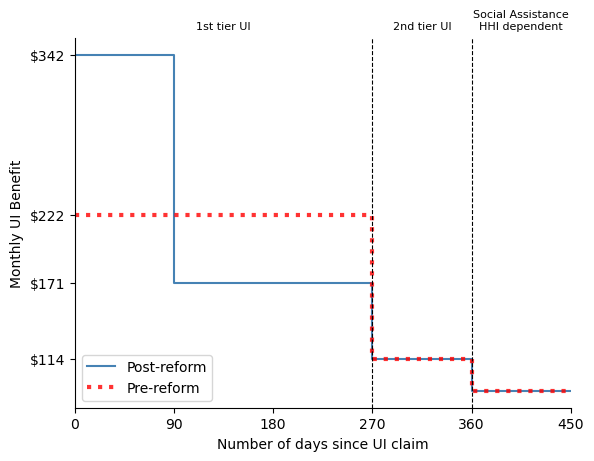

In [47]:
import numpy as np
import matplotlib.pyplot as plt

# Duplicate the x-values where drops occur to create vertical lines
pre_x =   [0, 90, 90, 180, 270, 270, 270, 360, 360, 360, 450]           # making the axis for pre
pre_y =   [222, 222, 222, 222, 222, 114, 114, 114, 90,  90,  90]        # making the values for pre


post_x =  [0, 90, 90, 180, 270, 270, 360, 360, 450]                     # making the axis for post
post_y =  [342, 342, 171, 171, 171, 114, 114, 90,  90]                  # making the values for post

fig, ax = plt.subplots()

ax.plot(post_x, post_y, label='Post-reform', color='steelblue')
ax.plot(pre_x, pre_y, label='Pre-reform', color='red',
        linestyle='dotted', linewidth=3, alpha=0.8)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Vertical lines at 270, 360
for x in [270, 360]:
    ax.axvline(x=x, color='black', linestyle='--', linewidth=0.8)

ax.set_xlim(0, 450)

sections = [(0, 270, '1st tier UI'), (270, 360, '2nd tier UI'), (360, 450, 'Social Assistance\nHHI dependent')]
x_min, x_max = 0, 450
for x_start, x_end, label in sections:
    x_mid_axes = ((x_start + x_end) / 2 - x_min) / (x_max - x_min)
    ax.text(x_mid_axes, 1.02, label, ha='center', va='bottom',
            transform=ax.transAxes, clip_on=False, fontsize=8)


ax.set_xticks([0, 90, 180, 270, 360, 450])
ax.set_yticks([114, 171, 222, 342])
ax.set_yticklabels(['$114', '$171', '$222', '$342'])

ax.set_xlabel('Number of days since UI claim')
ax.set_ylabel('Monthly UI Benefit')

ax.legend() 

plt.savefig('/Users/albertolsen/Documents/Stud Polit/9. semester/Dynamic Programming/Exam/termpaper_dynprog/Figurer/benefits_path.pdf', bbox_inches='tight')
plt.show()



### Here we plot the empirical survival and hazard rates

In [17]:
momentsfile = './base_moments_Hungary.xlsx'
    
moments_df  = pd.read_excel(momentsfile, index_col=0)
moments_hazard_pre = moments_df['before_b'].to_numpy()
moments_hazard_post = moments_df['after_b'].to_numpy()

moments_hazard_pre = moments_hazard_pre[1:]
moments_hazard_post = moments_hazard_post[1:]

Plotting the hazard rates

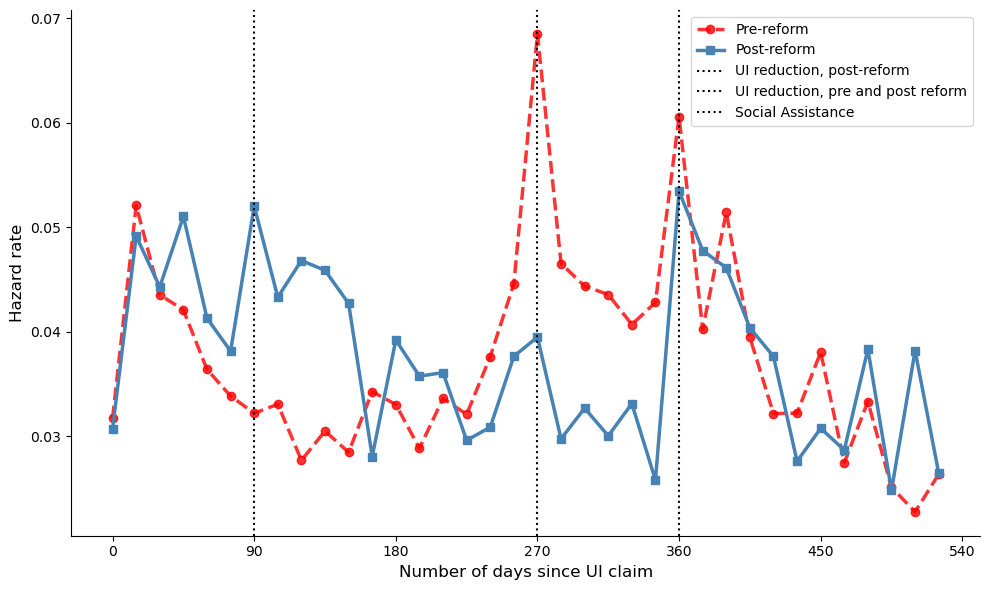

In [54]:
import numpy as np
import matplotlib.pyplot as plt

# 37 periods × 15 days
days = np.arange(36) * 15

fig, ax = plt.subplots(figsize=(10, 6))

# Pre-reform: dotted line + circle markers
ax.plot(
    days,
    moments_hazard_pre,
    label='Pre-reform',
    color='red',
    linestyle='--',
    marker='o',
    linewidth=2.5,
    markersize=6,
    alpha=0.8
)

# Post-reform: solid line + square markers
ax.plot(
    days,
    moments_hazard_post,
    label='Post-reform',
    color='steelblue',
    linestyle='-',
    marker='s',
    linewidth=2.5,
    markersize=6
)

# Vertical lines — change the x-values and labels as desired
ax.axvline(90, color='black', linestyle=':', linewidth=1.5, label='UI reduction, post-reform')
ax.axvline(270, color='black', linestyle=':', linewidth=1.5, label='UI reduction, pre and post reform')
ax.axvline(360, color='black', linestyle=':', linewidth=1.5, label='Social Assistance')


# X-axis: every 90 days
ax.set_xticks(np.arange(0, 541, 90))

# Labels
ax.set_xlabel('Number of days since UI claim', fontsize=12)
ax.set_ylabel('Hazard rate', fontsize=12)

# Legend
ax.legend()

# Optional: clean up appearance
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()

plt.savefig('/Users/albertolsen/Documents/Stud Polit/9. semester/Dynamic Programming/Exam/termpaper_dynprog/Figurer/Hazard rates.pdf', bbox_inches='tight')
plt.show()

We make the survival rates

In [39]:
# Making the empirical survival rates
survival_pre = np.zeros(37)

survival_pre[0] = 1
survival_pre[1:] = np.cumprod(1 - moments_hazard_pre[:])

print(survival_pre)

[1.         0.96827914 0.91784298 0.8778747  0.8409199  0.81030928
 0.78287074 0.75765266 0.73259318 0.71229183 0.69056305 0.67089611
 0.64789849 0.62648692 0.60840603 0.58794608 0.56907217 0.54766059
 0.52323553 0.48739096 0.46471055 0.44409199 0.42474227 0.4074544
 0.39000793 0.36637589 0.35162569 0.33354481 0.32038065 0.31007137
 0.3000793  0.28865979 0.28072958 0.27137193 0.26455194 0.25852498
 0.251705  ]


In [40]:
survival_post = np.zeros(37)

survival_post[0] = 1
survival_post[1:] = np.cumprod(1 - moments_hazard_post[:])

print(survival_post)

[1.         0.96925014 0.92159683 0.88077684 0.83582089 0.80129473
 0.77072469 0.73062399 0.698975   0.66624707 0.63567703 0.60852364
 0.59144039 0.56824312 0.54792303 0.52814242 0.51249775 0.49667326
 0.47797158 0.45909009 0.44542348 0.43085776 0.41791045 0.40406401
 0.39363424 0.37259485 0.3547923  0.33842834 0.32476173 0.31253372
 0.30390217 0.29455134 0.28609962 0.27513037 0.26829707 0.25804711
 0.25121381]


Plotting the survival rates

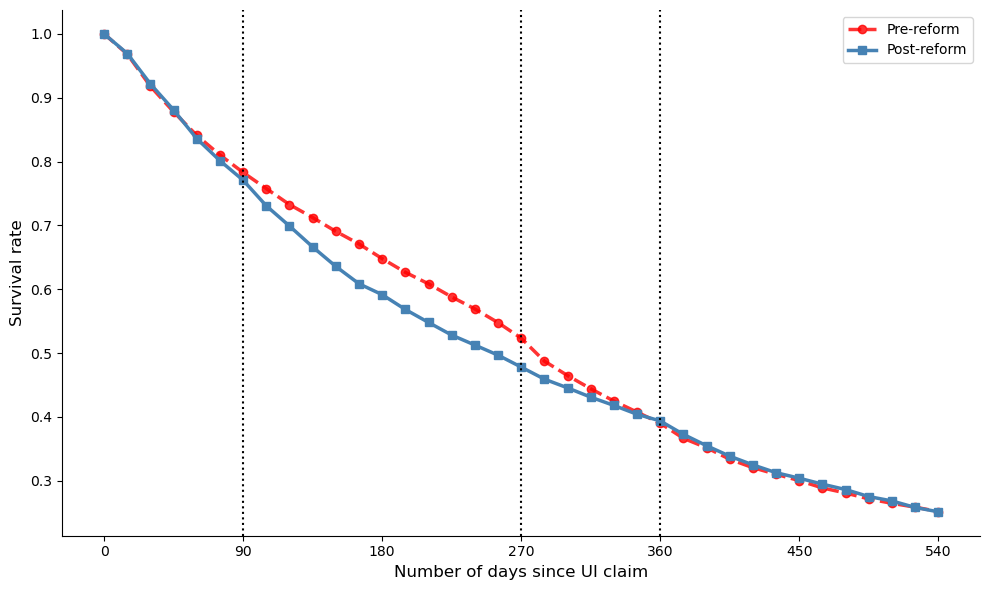

In [53]:
import numpy as np
import matplotlib.pyplot as plt

# 37 periods × 15 days
days = np.arange(37) * 15

fig, ax = plt.subplots(figsize=(10, 6))

# Pre-reform: dashed line + circle markers
ax.plot(
    days,
    survival_pre,
    label='Pre-reform',
    color='red',
    linestyle='--',
    marker='o',
    linewidth=2.5,
    markersize=6,
    alpha=0.8
)

# Post-reform: solid line + square markers
ax.plot(
    days,
    survival_post,
    label='Post-reform',
    color='steelblue',
    linestyle='-',
    marker='s',
    linewidth=2.5,
    markersize=6
)

# Three vertical lines, without names
ax.axvline(90, color='black', linestyle=':', linewidth=1.5)
ax.axvline(270, color='black', linestyle=':', linewidth=1.5)
ax.axvline(360, color='black', linestyle=':', linewidth=1.5)

# X-axis: every 90 days
ax.set_xticks(np.arange(0, 541, 90))

# Labels
ax.set_xlabel('Number of days since UI claim', fontsize=12)
ax.set_ylabel('Survival rate', fontsize=12)

# Legend
ax.legend()

# Clean up appearance
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()

plt.savefig('/Users/albertolsen/Documents/Stud Polit/9. semester/Dynamic Programming/Exam/termpaper_dynprog/Figurer/Survival rates.pdf', bbox_inches='tight')

plt.show()